In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

plt.style.use('ggplot')

# Handling Missing Values for Inference

So far we shaped and reduced our predictors while assuming the dataset was complete. In the real world this is rarely the case, and we often have incomplete data. In these cases, one of the most important things is to correctly classify these missing values. Are they missing at random (MAR), missing completely at random (MCAR) or missing not at random (MNAR)? For details, please refer to this Wikipedia [link](https://en.wikipedia.org/wiki/Missing_data).

All these require different procedures. MCAR is safest to impute since it is not correlated with other predictors. Using a central tendency metric would often work fine, though it reduces variance and standard errors. We can adopt more sophisticated imputation methods to recover this lost variance.

We can use imputation in MAR conditions too, but we need to be more creative. Since missing values are correlated with other observed variables, we can use more complicated imputation strategies that take this relationship into consideration.

Conversely, imputation in MNAR condition is often wrong. The missingness depends on the unobserved value itself, so no imputation method can recover the true mechanism. Therefore forcefully filling them can be misleading.

Let's see a couple of examples.


### Missing Completely at Random (MCAR) 

Let's say we have a dataset about customer details. We know that missing values are completely random. One of the features having missing value is height.

$n = 200, \quad n_{\text{missing}} = 10$

$h \sim \mathcal{N}(170,\ 5^2) \quad \text{(height)}$


Number of data points: 210
Number of missing values: 10


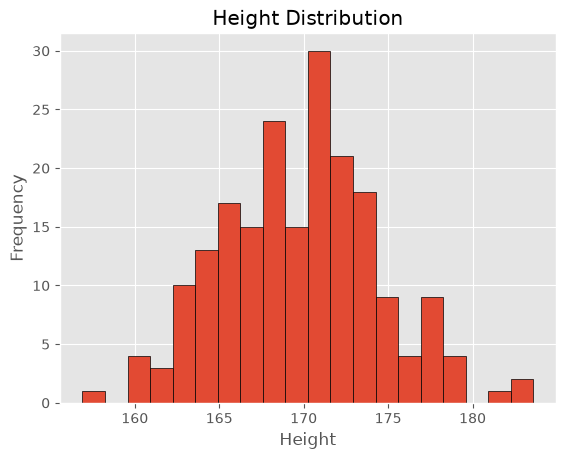

In [2]:
np.random.seed(42)
height = np.random.normal(loc = 170, scale = 5, size = 200)
height = np.append(height, [np.nan]*10)

print("Number of data points:", len(height))
print("Number of missing values:", np.sum(np.isnan(height)))

plt.figure()
plt.hist(height, bins=20, edgecolor='k')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Height Distribution')
plt.show()

The data is centered around the mean and standard deviation is not extreme. Hence we can use mean statistic to fill the null values. 

In [3]:
null_index = np.isnan(height)
height[null_index] = np.nanmean(height)

By doing that, we assume that the missing data has the same characteristics as the rest. It is not a bad assumption necessarily but we need to keep this in mind to avoid overconfidence. For example if we fit a regression model to this data, standard error of the height variable will be smaller since the imputed values carry no real uncertainty.

### Missing at Random (MAR) 

Let's say we have blood pressure and age data. Some of the blood pressure values are missing. Younger individuals tend to go to regular checkups less frequently, so their blood pressure is less likely to be measured and recorded. Since

1. The missingness mechanism is captured by another variable (age), not by blood pressure's own value
2. Age is correlated with blood pressure,

we can use age for the imputation.

$n = 200$

$a \sim U(25,65) \quad \text{(age)}$

$b^{\text{true}} = 90 + 0.5\,a + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,\ 6^2) \quad \text{(blood pressure)}$

$p_i = P(M_i=1\mid a_i) = \frac{1}{1+\exp\left(\frac{a_i-45}{8}\right)}$

where $M_i=1$ means blood pressure is missing. The observed blood pressure is

$b_i =
\begin{cases}
\text{NaN}, & M_i=1 \\
b_i^{\text{true}}, & M_i=0
\end{cases}$


In [4]:
np.random.seed(42)
n = 200
a = np.random.uniform(25,65, n)
b = 90 + 0.5*a + np.random.normal(0, 6, n)
p = 1/(1 + np.exp((a-45)/8))
b = np.where(np.random.rand(n) < p, np.nan, b)

data = pd.DataFrame({
    "age": a,
    "blood_pressure": b
})

print("Number of data points:", len(data))
print("Number of missing values:", data['blood_pressure'].isna().sum())
data.head(3)

Number of data points: 200
Number of missing values: 97


,age,blood_pressure
0,39.981605,NaN
1,63.028572,122.907808
2,54.279758,NaN


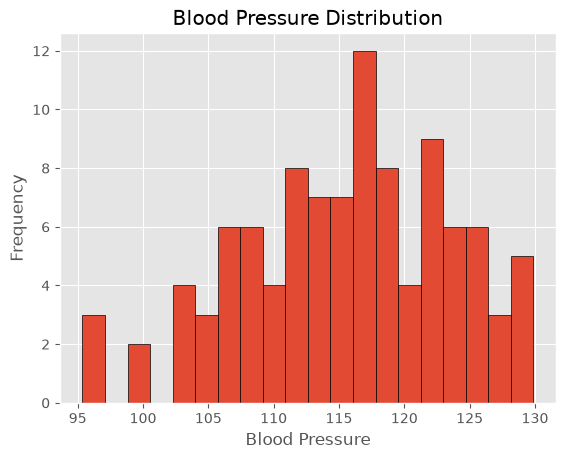

In [5]:
plt.figure()
plt.hist(data['blood_pressure'].dropna(), bins=20, edgecolor='k')
plt.xlabel('Blood Pressure')
plt.ylabel('Frequency')
plt.title('Blood Pressure Distribution')
plt.show()

In [6]:
model = smf.ols('blood_pressure ~ age', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         blood_pressure   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     94.24
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           3.95e-16
Time:                        10:42:13   Log-Likelihood:                -325.40
No. Observations:                 103   AIC:                             654.8
Df Residuals:                     101   BIC:                             660.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     89.0610      2.777     32.071      0.0

In [7]:
missing_data = data[data['blood_pressure'].isna()].copy(deep=True)
predictions = model.predict(missing_data[['age']])
missing_data['blood_pressure'] = predictions
missing_data.head(5)

,age,blood_pressure
0,39.981605,110.114326
2,54.279758,117.643378
4,31.240746,105.511607
5,31.239781,105.511099
6,27.323344,103.448802


### Missing Not at Random (MNAR) 

Let's say we have height and weight variables this time. Some of the weight values are missing, because heavier people tend not to report their weight. Since the mechanism behind the missing values is tied to weight's own unobserved value, we cannot use height (or any other observed variable) to reliably fill the missing weight values.

## Incorporating Uncertainty

So far we saw different ways to impute missing values. There are plenty of more complicated methods as well. They are often used in common ML tools such as LightGBM, CatBoost and XGBoost. Even XGBoost has its own imputing algorithm designed specifically for filling missing values.

The problem with these approaches is that they do not incorporate uncertainty. They are optimized to make better predictions, not to make inferences. To make successful inferences, we need to model the uncertainty as well. The question is how?



In his book, Harrell describes a unique way:

For M bootstrap samples,

1. Fit a regression model predicting the variable with missing values, using other predictors (including the target $Y$ as a predictor for the imputation model).
2. Predict the missing values using this regression.
3. Find the real, observed value with the closest prediction (predictive mean matching) and use it to fill the missing values, instead of using the predicted value directly.
4. With this completed dataset, fit the actual analysis model (e.g. a regression of $Y$ on $X$).
5. Record $\beta_i$ from the analysis model, along with its standard error.

After M iterations, combine all $\beta_i$ and standard errors using Rubin's rules to make inferences on $\beta$.

Harrell also advises using restricted cubic splines to model nonlinear relationships.

M is usually chosen between 20 and 30.

Let's see an example.

### Example

$n = 300$

$\text{age} \sim U(25, 65)$

$\text{exercise} \sim \mathcal{N}(3,\ 1.5^2) \quad \text{(clipped at 0)}$

$\text{cholesterol} = 150 + 1.2\,\text{age} - 8\,\text{exercise} + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,\ 15^2)$

$\text{weight}^{\text{true}} = 50 + 0.4\,\text{age} - 2\,\text{exercise} + 0.15\,\text{cholesterol} + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,\ 8^2)$

$p_i = P(M_i=1\mid \text{age}_i) = \frac{1}{1+\exp\left(-\frac{\text{age}_i-45}{8}\right)}$

where $M_i=1$ means weight is missing. The observed weight is

$\text{weight}_i =
\begin{cases}
\text{NaN}, & M_i=1 \\
\text{weight}_i^{\text{true}}, & M_i=0
\end{cases}$


In [8]:
np.random.seed(42)
n = 300
age = np.random.uniform(25, 65, n)
exercise_hours = np.random.normal(3, 1.5, n).clip(0, None)

cholesterol = 150 + 1.2 * age - 8 * exercise_hours + np.random.normal(0, 15, n)
weight_true = 50 + 0.4 * age - 2 * exercise_hours + 0.15 * cholesterol + np.random.normal(0, 8, n)

p_missing = 1 / (1 + np.exp(-(age - 45) / 8))
missing_mask = np.random.rand(n) < p_missing

weight = weight_true.copy()
weight[missing_mask] = np.nan

data = pd.DataFrame({
    "age": age,
    "exercise_hours": exercise_hours,
    "cholesterol": cholesterol,
    "weight": weight
})

print("Number of missing values:", data['weight'].isna().sum())
data.head()


Number of missing values: 156


,age,exercise_hours,cholesterol,weight
0,39.981605,3.068358,172.439867,77.688780
1,63.028572,2.022599,191.288248,NaN
2,54.279758,6.215916,155.630839,82.347217
3,48.946339,3.950879,177.839559,NaN
4,31.240746,0.000000,174.582694,101.087706


In [9]:
np.random.seed(42)
M = 20
random_states = np.random.randint(0, 10000, M)
known_columns = ['age', 'exercise_hours', 'cholesterol']
observed_mask = data['weight'].notna()

betas = []
ses = []

for i in range(M):
    boot_obs = data[observed_mask].sample(frac=1, replace=True, random_state=random_states[i])
    impute_model = smf.ols('weight ~ age + exercise_hours + cholesterol', data=boot_obs).fit()
    missing_data = data[~observed_mask].copy()
    missing_data['weight_pred'] = impute_model.predict(missing_data[known_columns])

    boot_obs_pred = impute_model.predict(boot_obs[known_columns])
    donor_pool = boot_obs['weight'].values
    donor_preds = boot_obs_pred.values

    filled_weights = []
    for pred in missing_data['weight_pred']:
        closest_idx = np.argmin(np.abs(donor_preds - pred))
        filled_weights.append(donor_pool[closest_idx])

    completed = data.copy()
    completed.loc[~observed_mask, 'weight'] = filled_weights

    analysis_model = smf.ols('cholesterol ~ age + exercise_hours + weight', data=completed).fit()

    betas.append(analysis_model.params)
    ses.append(analysis_model.bse)

betas = pd.DataFrame(betas)
ses = pd.DataFrame(ses)

In [10]:
betas.head()

,Intercept,age,exercise_hours,weight
0,112.817955,0.818854,-6.433485,0.557185
1,120.945466,0.878601,-6.614850,0.446174
2,123.195519,0.907716,-6.521785,0.400840
3,121.374290,0.895969,-6.691844,0.434474
4,112.863343,0.811889,-6.063810,0.545379


Now we only need to combine these $\beta$ values using Rubin's rules for final reporting.

$\bar{\beta} = \frac{1}{M}\sum_{i=1}^{M} \beta_i$

$\bar{V}_W = \frac{1}{M}\sum_{i=1}^{M} \text{SE}_i^2 \quad \text{(within-imputation variance)}$

$V_B = \frac{1}{M-1}\sum_{i=1}^{M} (\beta_i - \bar{\beta})^2 \quad \text{(between-imputation variance)}$

$V_{\text{total}} = \bar{V}_W + V_B + \frac{V_B}{M}$

$\text{SE}(\bar{\beta}) = \sqrt{V_{\text{total}}}$

In [11]:
beta_pooled = betas.mean()
within_var = (ses ** 2).mean()
between_var = betas.var(ddof=1)
total_var = within_var + between_var + (between_var / M)

pooled_se = np.sqrt(total_var)
df_old = (M - 1) * (1 + within_var / ((1 + 1/M) * between_var)) ** 2

t_crit = stats.t.ppf(0.975, df_old)

summary = pd.DataFrame({
    'beta': beta_pooled,
    'se': pooled_se,
    'ci_lower': beta_pooled - t_crit * pooled_se,
    'ci_upper': beta_pooled + t_crit * pooled_se
})

summary

,beta,se,ci_lower,ci_upper
Intercept,117.026134,9.685138,97.951072,136.101197
age,0.852662,0.095512,0.664737,1.040587
exercise_hours,-6.343922,0.720680,-7.758677,-4.929167
weight,0.491929,0.114530,0.265961,0.717896


Rubin's rules combine the M results into a single coefficient and standard error. The standard error now also captures how much the estimates varied across imputations. This is a better approach for inference since it prevents the naive optimism caused by single-value imputation.
